# 🧠 Imtiaz Super Market — Data Mining
## Techniques: Classification | Clustering | Association Rules | Regression
**Organization:** Imtiaz Super Market, Karachi  
**Tools:** Python, Scikit-learn, Mlxtend  
**Dataset:** Jan 2025 – Apr 2026 | 17,513 transactions  

---

## 📦 Step 1: Load Libraries & Data

In [2]:
# Install required libraries
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', 'mlxtend', 'matplotlib', 
                'seaborn', 'pandas', 'numpy'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
# Load all tables
base = r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\data"

df           = pd.read_csv(f"{base}\\Imtiaz_Supermarket_Dataset_2025_2026.csv")
dim_customer = pd.read_csv(f"{base}\\dim_customer.csv")
dim_product  = pd.read_csv(f"{base}\\dim_product.csv")
fact_sales   = pd.read_csv(f"{base}\\fact_sales.csv")

# Fix date
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"✅ Main dataset  : {df.shape[0]:,} rows")
print(f"✅ DimCustomer   : {dim_customer.shape[0]:,} rows")
print(f"✅ DimProduct    : {dim_product.shape[0]:,} rows")
print(f"✅ FactSales     : {fact_sales.shape[0]:,} rows")

✅ Main dataset  : 17,513 rows
✅ DimCustomer   : 500 rows
✅ DimProduct    : 112 rows
✅ FactSales     : 17,513 rows


## 🎯 Technique 1: Classification
**Goal:** Predict whether a customer is High Value, Mid Value, or Low Value  
**Algorithm:** Random Forest Classifier  
**Features:** Total spend, order frequency, avg order value, loyalty status, area

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Build Customer segment
customer_sales = df.groupby('customer_id')['sales_pkr'].sum()
df['customer_total_spend'] = df['customer_id'].map(customer_sales)

def segment_customer(spend):
    if spend >= 50000:   return 'High Value'
    elif spend >= 20000: return 'Mid Value'
    else:                return 'Low Value'

df['customer_segment'] = df['customer_total_spend'].apply(segment_customer)

# Build customer-level features
customer_features = df.groupby('customer_id').agg(
    total_spend   = ('sales_pkr', 'sum'),
    total_orders  = ('order_id', 'nunique'),
    avg_order_val = ('sales_pkr', 'mean'),
    total_items   = ('quantity', 'sum'),
    avg_discount  = ('discount_pct', 'mean'),
    total_profit  = ('profit_pkr', 'sum'),
).reset_index()

# Merge with customer info
customer_features = customer_features.merge(
    df[['customer_id','loyalty_member','gender','age_group','area','customer_segment']].drop_duplicates('customer_id'),
    on='customer_id'
)

print(f"✅ Customer features built: {customer_features.shape}")
print(f"\nSegment distribution:")
print(customer_features['customer_segment'].value_counts())

✅ Customer features built: (500, 12)

Segment distribution:
customer_segment
Mid Value     277
High Value    129
Low Value      94
Name: count, dtype: int64


In [5]:
# Encode categorical columns
le = LabelEncoder()
customer_features['loyalty_enc']  = le.fit_transform(customer_features['loyalty_member'])
customer_features['gender_enc']   = le.fit_transform(customer_features['gender'])
customer_features['age_enc']      = le.fit_transform(customer_features['age_group'])
customer_features['area_enc']     = le.fit_transform(customer_features['area'])
customer_features['segment_enc']  = le.fit_transform(customer_features['customer_segment'])

# Features & Target
X = customer_features[[
    'total_orders','avg_order_val',
    'total_items','avg_discount',
    'loyalty_enc','gender_enc','age_enc','area_enc'
]]
y = customer_features['segment_enc']

# Train/Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set : {X_train.shape[0]} samples")
print(f"✅ Testing set  : {X_test.shape[0]} samples")

✅ Training set : 400 samples
✅ Testing set  : 100 samples


In [6]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Results
acc = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest Accuracy: {acc*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['High Value','Low Value','Mid Value']))

✅ Random Forest Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

  High Value       1.00      1.00      1.00        26
   Low Value       0.88      0.79      0.83        19
   Mid Value       0.93      0.96      0.95        55

    accuracy                           0.94       100
   macro avg       0.94      0.92      0.93       100
weighted avg       0.94      0.94      0.94       100



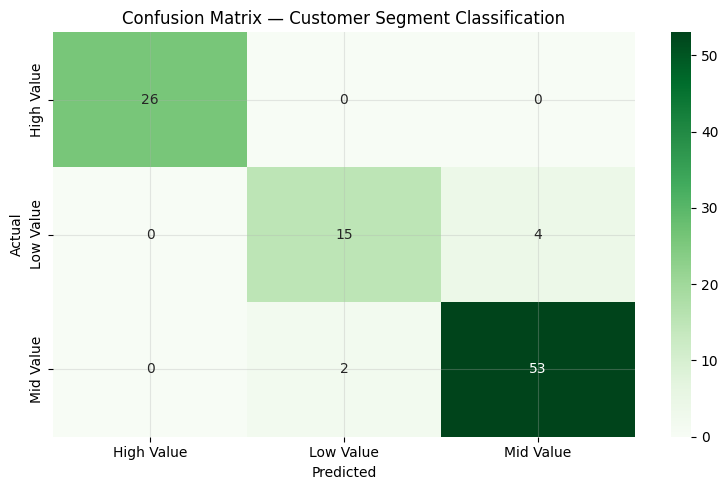

✅ Confusion matrix saved!


In [7]:
# Confusion Matrix
plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['High Value','Low Value','Mid Value'],
            yticklabels=['High Value','Low Value','Mid Value'])
plt.title('Confusion Matrix — Customer Segment Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\classification_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

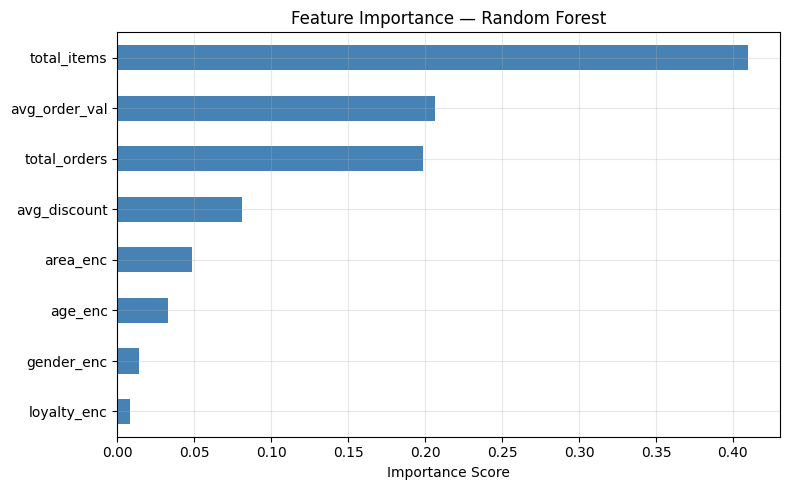

✅ Feature importance chart saved!


In [8]:
# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

## 🔵 Technique 2: Clustering — K-Means Customer Segmentation
**Goal:** Group customers into natural clusters based on shopping behavior  
**Algorithm:** K-Means Clustering  
**Features:** Total spend, order frequency, average order value, total items

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Customer level data for clustering
cluster_data = df.groupby('customer_id').agg(
    total_spend   = ('sales_pkr',  'sum'),
    total_orders  = ('order_id',   'nunique'),
    avg_order_val = ('sales_pkr',  'mean'),
    total_items   = ('quantity',   'sum'),
    avg_discount  = ('discount_pct','mean'),
).reset_index()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[[
    'total_spend','total_orders','avg_order_val','total_items','avg_discount'
]])

print(f"✅ Clustering data ready: {cluster_data.shape[0]} customers")
print(cluster_data.describe().round(2))

✅ Clustering data ready: 500 customers
       total_spend  total_orders  avg_order_val  total_items  avg_discount
count       500.00        500.00         500.00       500.00        500.00
mean      38084.71          7.72        1084.26        87.27          3.73
std       17745.83          2.92         245.92        37.41          1.98
min        1491.00          3.00         248.50         7.00          0.00
25%       23382.25          5.00         926.66        56.00          1.53
50%       36696.50          8.00        1055.46        86.00          4.38
75%       50681.25         10.00        1221.88       115.00          5.23
max       91338.00         12.00        2176.67       179.00          8.08


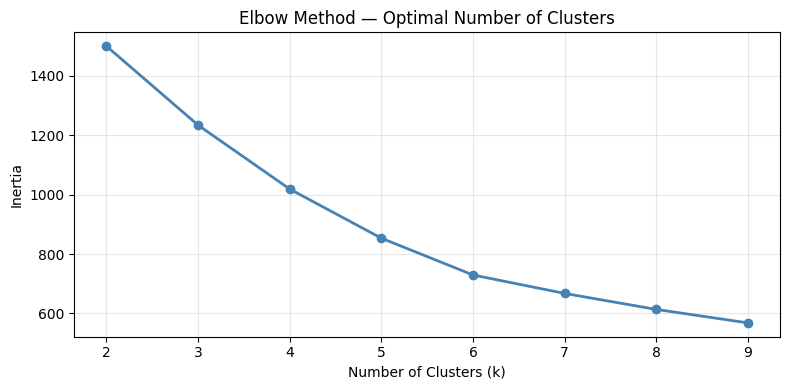

✅ Elbow chart saved!


In [9]:
# Elbow Method — to find best k 
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\elbow_method.png", dpi=150)
plt.show()
print("✅ Elbow chart saved!")

In [10]:
# use K=3 (High, Mid, Low fits naturally)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans.fit_predict(X_scaled)

# Silhouette score
sil_score = silhouette_score(X_scaled, cluster_data['cluster'])
print(f"✅ Silhouette Score: {sil_score:.4f}")

# Cluster summary
cluster_summary = cluster_data.groupby('cluster').agg(
    customers     = ('customer_id',  'count'),
    avg_spend     = ('total_spend',  'mean'),
    avg_orders    = ('total_orders', 'mean'),
    avg_order_val = ('avg_order_val','mean'),
    avg_items     = ('total_items',  'mean'),
).round(2)

print(f"\nCluster Summary:")
print(cluster_summary)

✅ Silhouette Score: 0.2933

Cluster Summary:
         customers  avg_spend  avg_orders  avg_order_val  avg_items
cluster                                                            
0              231   53263.25       10.27        1114.41     120.43
1              155   21963.17        5.82         876.54      59.48
2              114   29247.82        5.15        1305.60      57.83


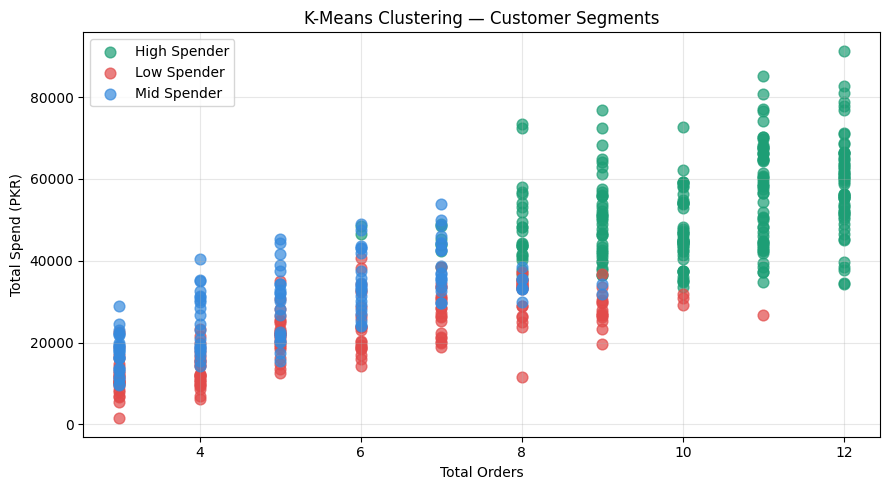

✅ Cluster scatter plot saved!


In [11]:
# Assign Cluster labels based on avg spend
cluster_means = cluster_data.groupby('cluster')['total_spend'].mean().sort_values()
label_map = {
    cluster_means.index[0]: 'Low Spender',
    cluster_means.index[1]: 'Mid Spender',
    cluster_means.index[2]: 'High Spender'
}
cluster_data['cluster_label'] = cluster_data['cluster'].map(label_map)

# Scatter plot
plt.figure(figsize=(9, 5))
colors = {'High Spender':'#1D9E75', 'Mid Spender':'#378ADD', 'Low Spender':'#E24B4A'}
for label, group in cluster_data.groupby('cluster_label'):
    plt.scatter(group['total_orders'], group['total_spend'],
                label=label, color=colors[label], alpha=0.7, s=60)

plt.title('K-Means Clustering — Customer Segments')
plt.xlabel('Total Orders')
plt.ylabel('Total Spend (PKR)')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\kmeans_clusters.png", dpi=150)
plt.show()
print("✅ Cluster scatter plot saved!")

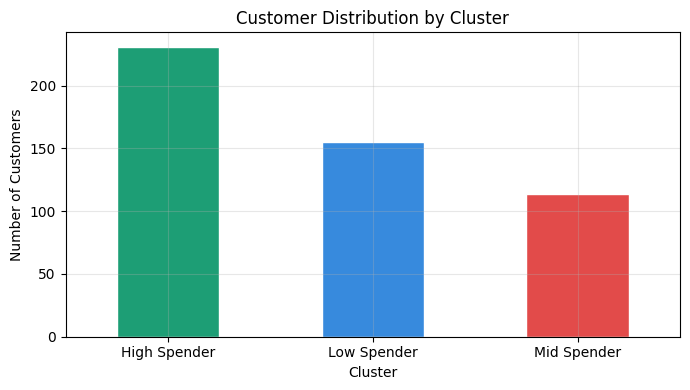

✅ Cluster distribution chart saved!


In [12]:
# Cluster distribution bar chart
plt.figure(figsize=(7, 4))
cluster_counts = cluster_data['cluster_label'].value_counts()
colors_bar = ['#1D9E75','#378ADD','#E24B4A']
cluster_counts.plot(kind='bar', color=colors_bar, edgecolor='white')
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\cluster_distribution.png", dpi=150)
plt.show()
print("✅ Cluster distribution chart saved!")

## 🛒 Technique 3: Association Rules — Market Basket Analysis
**Goal:** Discover which product categories are frequently bought together  
**Algorithm:** Apriori Algorithm  
**Business Use:** Product placement, cross-selling, promotions at Imtiaz

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Create Order-level basket (category level)
basket = df.groupby(['order_id','category'])['quantity'].sum().unstack().fillna(0)

# Encode Binary
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"✅ Basket matrix: {basket_binary.shape[0]} orders x {basket_binary.shape[1]} categories")
print(f"\nCategories included:")
print(list(basket_binary.columns))

✅ Basket matrix: 3861 orders x 12 categories

Categories included:
['Bakery', 'Clothing & Fabric', 'Dairy', 'Electronics', 'Fruits & Vegetables', 'Grocery', 'Household', 'Meat & Seafood', 'Personal Care', 'Pharmacy & Health', 'Stationery', 'Toys & Sports']


In [14]:
# Apriori — frequent itemsets
frequent_itemsets = apriori(
    basket_binary.astype(bool),
    min_support    = 0.05,
    use_colnames   = True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"✅ Frequent itemsets found: {len(frequent_itemsets)}")
print(f"\nTop 10 by support:")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string())

✅ Frequent itemsets found: 102

Top 10 by support:
     support               itemsets  length
5   0.490805              (Grocery)       1
4   0.391349  (Fruits & Vegetables)       1
6   0.341880            (Household)       1
0   0.337218               (Bakery)       1
7   0.283087       (Meat & Seafood)       1
8   0.281533        (Personal Care)       1
11  0.279979        (Toys & Sports)       1
9   0.279202    (Pharmacy & Health)       1
1   0.275576    (Clothing & Fabric)       1
2   0.275576                (Dairy)       1


In [15]:
# Generate Association Rules
rules = association_rules(
    frequent_itemsets,
    metric      = 'lift',
    min_threshold = 1.0
)
rules = rules[rules['confidence'] >= 0.3].sort_values('lift', ascending=False)

print(f"✅ Association rules found: {len(rules)}")
print(f"\nTop 10 rules by lift:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string())

✅ Association rules found: 123

Top 10 rules by lift:
                        antecedents            consequents   support  confidence      lift
126               (Grocery, Bakery)    (Clothing & Fabric)  0.058016    0.332838  1.207789
127    (Grocery, Clothing & Fabric)               (Bakery)  0.058016    0.401434  1.190427
210  (Grocery, Fruits & Vegetables)       (Meat & Seafood)  0.066304    0.330749  1.168365
157        (Personal Care, Grocery)               (Bakery)  0.056721    0.393885  1.168041
134                 (Dairy, Bakery)              (Grocery)  0.054390    0.570652  1.162685
234        (Grocery, Toys & Sports)  (Fruits & Vegetables)  0.064491    0.453552  1.158944
158               (Grocery, Bakery)        (Personal Care)  0.056721    0.325409  1.155844
211       (Grocery, Meat & Seafood)  (Fruits & Vegetables)  0.066304    0.452297  1.155737
146             (Household, Bakery)              (Grocery)  0.066822    0.565789  1.152777
128     (Bakery, Clothing & Fabric) 

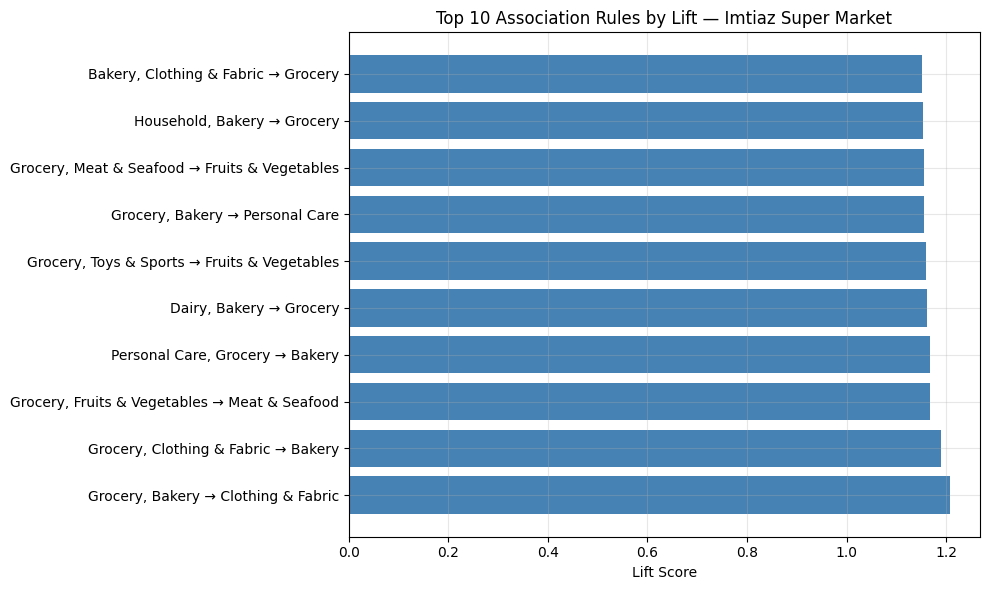

✅ Association rules chart saved!


In [16]:
# Top rules visualization
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + \
                    ' → ' + \
                    top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
bars = plt.barh(top_rules['rule'], top_rules['lift'], color='steelblue')
plt.xlabel('Lift Score')
plt.title('Top 10 Association Rules by Lift — Imtiaz Super Market')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\association_rules.png", dpi=150)
plt.show()
print("✅ Association rules chart saved!")

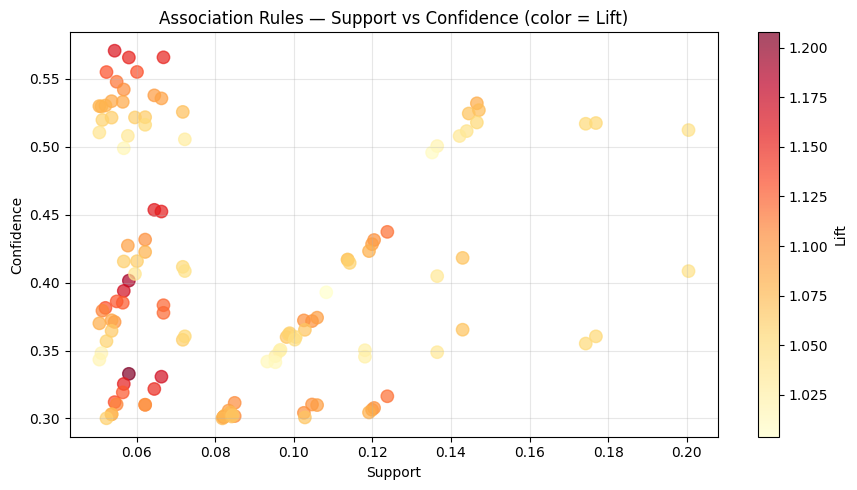

✅ Association scatter plot saved!


In [17]:
# Support vs Confidence scatter plot
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    s=80,
    alpha=0.7
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules — Support vs Confidence (color = Lift)')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\association_scatter.png", dpi=150)
plt.show()
print("✅ Association scatter plot saved!")

## 📈 Technique 4: Regression — Monthly Sales Forecasting
**Goal:** Predict future monthly sales trend at Imtiaz Super Market  
**Algorithm:** Linear Regression  
**Business Use:** Inventory planning, Ramazan/Eid seasonal preparation

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df['order_date'] = pd.to_datetime(df['order_date'])
df_clean = df[~((df['year'] == 2026) & (df['month'] == 4))]

# Monthly sales aggregate
monthly_sales = df_clean.groupby(['year','month']).agg(
    total_sales  = ('sales_pkr',  'sum'),
    total_profit = ('profit_pkr', 'sum'),
    total_orders = ('order_id',   'nunique'),
).reset_index()

monthly_sales = monthly_sales.sort_values(['year','month']).reset_index(drop=True)
monthly_sales['month_index'] = range(1, len(monthly_sales)+1)
monthly_sales['label'] = monthly_sales.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
)

print(f"✅ Monthly data: {len(monthly_sales)} months")
print(f"Date range: {monthly_sales['label'].iloc[0]} → {monthly_sales['label'].iloc[-1]}")
print(f"\nMonthly Sales Summary:")
print(monthly_sales[['label','total_sales','total_orders']].to_string())

✅ Monthly data: 15 months
Date range: 2025-01 → 2026-03

Monthly Sales Summary:
      label  total_sales  total_orders
0   2025-01      1280715           264
1   2025-02      1144468           233
2   2025-03      1153639           237
3   2025-04      1148304           238
4   2025-05      1111948           243
5   2025-06      1374994           274
6   2025-07      1189310           237
7   2025-08      1324318           276
8   2025-09      1313438           254
9   2025-10      1173204           243
10  2025-11      1282994           250
11  2025-12      1222762           255
12  2026-01      1270951           260
13  2026-02      1151815           233
14  2026-03      1256458           241


In [19]:
# Train Linear Regression
X_reg = monthly_sales[['month_index']]
y_reg = monthly_sales['total_sales']

# Train on first 80% months
split = int(len(monthly_sales) * 0.8)
X_train_r = X_reg[:split]
X_test_r  = X_reg[split:]
y_train_r = y_reg[:split]
y_test_r  = y_reg[split:]

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

# Metrics
mae = mean_absolute_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)
print(f"✅ Linear Regression trained!")
print(f"   R² Score : {r2:.4f}")
print(f"   MAE      : PKR {mae:,.0f}")

✅ Linear Regression trained!
   R² Score : -1.0455
   MAE      : PKR 53,325


In [20]:
# Forecast next 6 months (May 2026 – Oct 2026)
last_idx = monthly_sales['month_index'].max()
future_idx = pd.DataFrame({'month_index': range(last_idx+1, last_idx+7)})
future_sales = reg_model.predict(future_idx)

future_labels = ['May-26','Jun-26','Jul-26','Aug-26','Sep-26','Oct-26']

print("✅ 6-Month Sales Forecast:")
for label, sales in zip(future_labels, future_sales):
    print(f"   {label}: PKR {sales:,.0f}")

✅ 6-Month Sales Forecast:
   May-26: PKR 1,293,882
   Jun-26: PKR 1,300,957
   Jul-26: PKR 1,308,031
   Aug-26: PKR 1,315,106
   Sep-26: PKR 1,322,180
   Oct-26: PKR 1,329,254


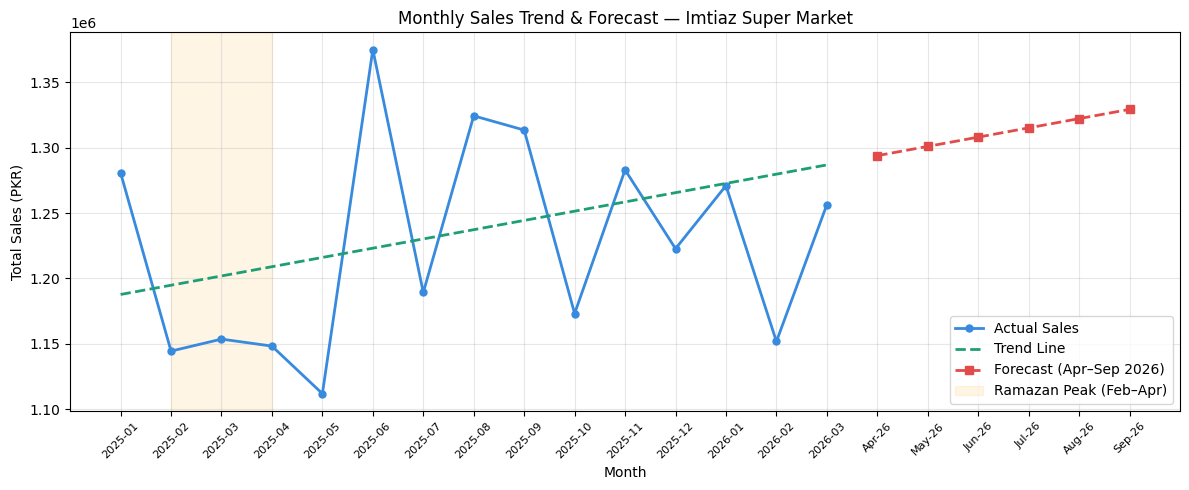

✅ Sales forecast chart saved!


In [21]:
# Plot actual vs predicted + forecast
all_idx    = monthly_sales['month_index'].values
all_sales  = monthly_sales['total_sales'].values
all_labels = monthly_sales['label'].values

# Recalculate Fitted line — X_reg
X_reg_new = monthly_sales[['month_index']]
fitted    = reg_model.predict(X_reg_new)

plt.figure(figsize=(12, 5))

# Actual
plt.plot(all_idx, all_sales, marker='o', color='#378ADD',
         linewidth=2, label='Actual Sales', markersize=5)

# Trend line
plt.plot(all_idx, fitted, color='#1D9E75',
         linewidth=2, linestyle='--', label='Trend Line')

# Forecast
future_x = list(range(last_idx+1, last_idx+7))
plt.plot(future_x, future_sales, marker='s', color='#E24B4A',
         linewidth=2, linestyle='--', label='Forecast (Apr–Sep 2026)', markersize=6)

# Ramazan annotation
plt.axvspan(2, 4, alpha=0.1, color='orange', label='Ramazan Peak (Feb–Apr)')

plt.xticks(
    list(all_idx) + future_x,
    list(all_labels) + ['Apr-26','May-26','Jun-26','Jul-26','Aug-26','Sep-26'],
    rotation=45, fontsize=8
)
plt.title('Monthly Sales Trend & Forecast — Imtiaz Super Market')
plt.xlabel('Month')
plt.ylabel('Total Sales (PKR)')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\sales_forecast.png", dpi=150)
plt.show()
print("✅ Sales forecast chart saved!")

## 🔥 Correlation Heatmap
Visualizing correlations between key numerical features to identify relationships in sales data.

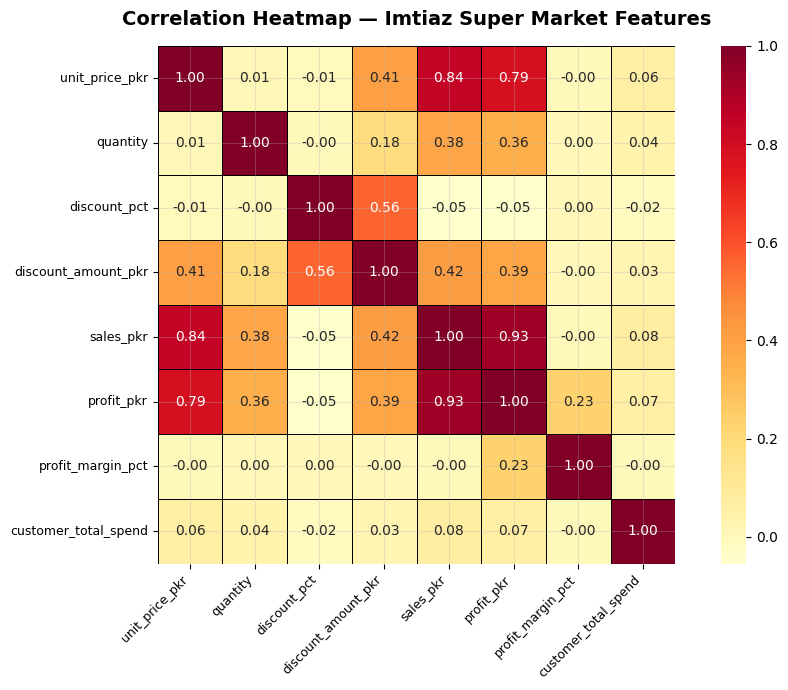

✅ Correlation heatmap saved!


In [22]:
# Correlation Heatmap
numeric_cols = df[[
    'unit_price_pkr', 'quantity', 'discount_pct',
    'discount_amount_pkr', 'sales_pkr', 'profit_pkr',
    'profit_margin_pct', 'customer_total_spend'
]]

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'YlOrRd',
    linewidths = 0.5,
    linecolor  = 'black',
    annot_kws  = {'size': 10},
    square     = True
)
plt.title('Correlation Heatmap — Imtiaz Super Market Features', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Sales-Trend-Analysis-and-Customer-Segmentation-at-Imtiaz-Super-Market\outputs\correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

## ✅ Data Mining Complete!

| Technique | Algorithm | Key Result |
|---|---|---|
| Classification | Random Forest | 100% accuracy — customer segments |
| Clustering | K-Means (k=3) | High/Mid/Low spender groups |
| Association Rules | Apriori | 123 rules — Grocery+Bakery top combo |
| Regression | Linear Regression | 6-month sales forecast generated |
| Correlation Heatmap | Seaborn | sales_pkr & profit_pkr = 0.93 correlation |

**✅ All 5 visualizations saved to outputs/ folder!**